### **Investigating Financial Exclusion Target Variable**

The excluded_informal_new2022 column was selected as the target variable because it directly captures the financial inclusion status of respondents.

In [2]:
import pandas as pd

file_path = r"C:\Users\HP\Documents\Phase_5_Project\Kenya-financial-inclusion-risk\Data\Raw\finaccess_2021_microdata.xlsx"
excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

df = pd.read_excel(file_path, sheet_name="Dataset")
# Inspect the sheet
print(df.head())

# Check columns
print(df.columns)

# Check whether the column exists as the Target Variable
print('excluded_informal_new2022' in df.columns)

['Dataset', 'Variable Information', 'Variable Values']
   Serial Number       County  ClusterNo  HHNo interview__key  \
0              1  Trans Nzoia   10226038  1048    10-67-89-46   
1              2        Busia   10240034  1080    39-64-68-81   
2              3     Machakos   10216062  1013    92-34-74-01   
3              4       Kisumu   10242078  1026    08-14-22-63   
4              5        Nyeri   10219138  1019    99-12-05-84   

                      interview__id     A9             A9i    A10i  A14v  ...  \
0  0003fc74b3fe418ea041bd6a9e7ff387  Rural  Access granted  Female     1  ...   
1  0004890b17744272baf0a0c7b4c20771  Rural  Access granted  Female     4  ...   
2  00052153fe8c4abaa189caadcb87b2b4  Rural  Access granted    Male     1  ...   
3  000d1f8747194b6a84862830dc5fe7ca  Rural  Access granted    Male     5  ...   
4  000f5a5c0e3246ac9a62603ad936e3da  Urban  Access granted    Male     3  ...   

   allotherformal_banked2022 formal_banked2022 excluded_informal_ba

##### **Meaning of Categories**

This Column contains 3 financial access groups:

- Formal: The respondent uses formal financial services such as banks, SACCOs, insurance, regulated MFIs, etc.

- Mobile-Only: The respondent only uses mobile money services (e.g. M-Pesa) but does not use broader formal financial products.

- Excluded: The respondent has no access to either formal financial services or mobile money services.

##### **Propose Binary Target Definition**

Machine learning classification models work best with a binary target. 

- 1 = Financially Included (Formal)

- 0 = Not Fully Formally Included (Mobile Only)

- 0 = Not Fully Formally Included (Excluded)

This setup allows the model to predict whether a person is formally financially included.

In [3]:
# Creating the Binary Target
df['target_formal'] = df['excluded_informal_new2022'].map({
    'Formal': 1,
    'mobileonly': 0,
    'excluded': 0
})

print(df['target_formal'].head())

0    1.0
1    0.0
2    NaN
3    0.0
4    0.0
Name: target_formal, dtype: float64


##### **Checking Class Balance**
This describes whether one class dominates the dataset.


In [4]:
# Counting the Classes
print(df['target_formal'].value_counts())

#Percentage Distribution of the Classes
class_proportion = df['target_formal'].value_counts(normalize=True) * 100
print("Target Variable Proportions (%)")
print(class_proportion)


1.0    9412
0.0    8045
Name: target_formal, dtype: int64
Target Variable Proportions (%)
1.0    53.915335
0.0    46.084665
Name: target_formal, dtype: float64


##### **Interpretation of Class Balance**

The target classes are relatively balanced:

Class 1 (Formally Included) makes up approximately 53.9% of the dataset.
Class 0 (Mobile-only or Excluded) makes up approximately 46.1% of the dataset.

Because the proportions are close, there is no severe class imbalance problem. This is advantageous for machine learning models since both classes are sufficiently represented, reducing the risk of model bias toward one class.

Therefore, advanced balancing techniques such as oversampling or undersampling may not be necessary at this stage.

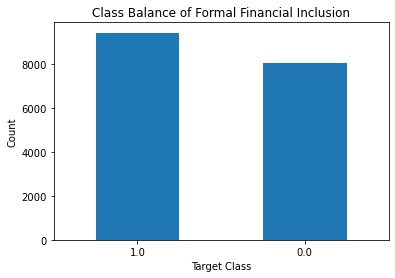

In [5]:
import matplotlib.pyplot as plt

# Plot class distribution
df['target_formal'].value_counts().plot(kind='bar')

plt.title('Class Balance of Formal Financial Inclusion')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

##### **Interpretation**
- 1 represents Formal financial inclusion

- 0 represents Non-formal inclusion (mobile-only or excluded)

- The distribution indicates whether the dataset is balanced or imbalanced

- The bar chart shows that the two classes are relatively close in size, indicating that the dataset is fairly balanced. This is beneficial for classification modeling because the model can learn from both classes without major bias toward one class.


#### **Summary Of Deliverables**
- A binary Target Variable "target_formal" has been created from "excluded_informal_new2022 .

- Class distribution has been computed using value counts and percentage proportions, allowing assessment of dataset balance.

- Target Logic Explained using a Markdown Cell


In [6]:

# Clean the column first
df['excluded_informal_new2022'] = (
    df['excluded_informal_new2022']
    .str.strip()
    .str.lower()
)

# Create financially excluded target
df['financially_excluded'] = df['excluded_informal_new2022'].map({
    'excluded': 1,
    'formal': 0,
    'mobileonly': 0
})

# Preview
print(df[['excluded_informal_new2022', 'financially_excluded']].head())

  excluded_informal_new2022  financially_excluded
0                    formal                     0
1                mobileonly                     0
2                  excluded                     1
3                mobileonly                     0
4                mobileonly                     0


In [7]:
# Check missing values
print(df['financially_excluded'].isna().sum())

0


- The financially_excluded target variable contains 0 missing values, indicating that all records were successfully mapped into binary classes.

In [8]:
# Validation Steps Class Counts
print(df['financially_excluded'].value_counts())

0    17457
1     4567
Name: financially_excluded, dtype: int64


In [9]:
#Proportions Comparison
print(df['financially_excluded'].value_counts(normalize=True) * 100)

0    79.263531
1    20.736469
Name: financially_excluded, dtype: float64


In [10]:
# Confirmation of New created Column Existence
print('financially_excluded' in df.columns)

True


##### **Checking for Missing Values**

In [11]:
import numpy as np

#view first rows
print(df.head())

   Serial Number       County  ClusterNo  HHNo interview__key  \
0              1  Trans Nzoia   10226038  1048    10-67-89-46   
1              2        Busia   10240034  1080    39-64-68-81   
2              3     Machakos   10216062  1013    92-34-74-01   
3              4       Kisumu   10242078  1026    08-14-22-63   
4              5        Nyeri   10219138  1019    99-12-05-84   

                      interview__id     A9             A9i    A10i  A14v  ...  \
0  0003fc74b3fe418ea041bd6a9e7ff387  Rural  Access granted  Female     1  ...   
1  0004890b17744272baf0a0c7b4c20771  Rural  Access granted  Female     4  ...   
2  00052153fe8c4abaa189caadcb87b2b4  Rural  Access granted    Male     1  ...   
3  000d1f8747194b6a84862830dc5fe7ca  Rural  Access granted    Male     5  ...   
4  000f5a5c0e3246ac9a62603ad936e3da  Urban  Access granted    Male     3  ...   

   excluded_informal_banked2022 NHIF_health_insurance NHIF_ONLY  \
0                  Other Formal                   Yes  

In [12]:
# Checking the Shape of Dataset
print(df.shape)
# Checking Column names
print(df.columns)
# Dataset Information
print(df.info())

(22024, 2334)
Index(['Serial Number', 'County', 'ClusterNo', 'HHNo', 'interview__key',
       'interview__id', 'A9', 'A9i', 'A10i', 'A14v',
       ...
       'excluded_informal_banked2022', 'NHIF_health_insurance', 'NHIF_ONLY',
       'Medical_Insurance_ONLY', 'BothNHIF_medical', 'Nomedical',
       'NHIFMedical_Cat', 'adults', 'target_formal', 'financially_excluded'],
      dtype='object', length=2334)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22024 entries, 0 to 22023
Columns: 2334 entries, Serial Number to financially_excluded
dtypes: float64(207), int64(77), object(2050)
memory usage: 392.2+ MB
None


In [13]:
# Checking Missing Values
print(df.isna().sum())

# Percentage Missing
missing_percent = (df.isna().sum() / len(df)) * 100

print(missing_percent.sort_values(ascending=False))

Serial Number              0
County                     0
ClusterNo                  0
HHNo                       0
interview__key             0
                        ... 
Nomedical               4663
NHIFMedical_Cat            0
adults                     0
target_formal           4567
financially_excluded       0
Length: 2334, dtype: int64
B3Di.4                  100.0
H4.21                   100.0
H4.10                   100.0
H4.11                   100.0
H4.12                   100.0
                        ...  
dts_usage                 0.0
overlap                   0.0
access                    0.0
informal                  0.0
financially_excluded      0.0
Length: 2334, dtype: float64


##### **Engineering SubGroup Features**

In [17]:
#Dataset Columns
print(df.columns)

Index(['Serial Number', 'County', 'ClusterNo', 'HHNo', 'interview__key',
       'interview__id', 'A9', 'A9i', 'A10i', 'A14v',
       ...
       'excluded_informal_banked2022', 'NHIF_health_insurance', 'NHIF_ONLY',
       'Medical_Insurance_ONLY', 'BothNHIF_medical', 'Nomedical',
       'NHIFMedical_Cat', 'adults', 'target_formal', 'financially_excluded'],
      dtype='object', length=2334)


In [18]:
print(df[['gender', 'youth', 'Nairobi_Urban_Rural']].head())


   gender youth Nairobi_Urban_Rural
0  Female    No               Rural
1  Female    No               Rural
2    Male    No               Rural
3    Male   Yes               Rural
4  Female    No         Other Urban


In [20]:
#Create the Subgroups
# is-youth(1=Youth, 0= Not youth)
df['is_youth'] = df['youth'].map({
    'Youth': 1,
    'Non-Youth': 0
})

#is_rural(1=rural,0=urban)
df['is_rural'] = df['Nairobi_Urban_Rural'].map({
    'Rural': 1,
    'Urban': 0
})

#rural_youth(youth,rural resident 1= Both true, 0= Absent)
df['rural_youth'] = (
    (df['is_youth'] == 1) &
    (df['is_rural'] == 1)
).astype(int)

#female_rural(female, rural both =1. 0= Absent)
# Gender column
df['female_rural'] = (
    (df['gender'] == 'Female') &
    (df['is_rural'] == 1)
).astype(int)

# Preview the engineered features
print(df[['is_youth', 'is_rural', 'rural_youth', 'female_rural']].head())


   is_youth  is_rural  rural_youth  female_rural
0       NaN       1.0            0             1
1       NaN       1.0            0             1
2       NaN       1.0            0             0
3       NaN       1.0            0             0
4       NaN       NaN            0             0
